<a href="https://colab.research.google.com/github/Auta01/Tensorflow-cases/blob/main/Buildng%20cnn%20binary%20classification%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

RE-INTRODUCTION TO COMPUTER VISION WITH TENSORFLOW

In [1]:
#geting our data
import zipfile

!wget https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
#unzip the downloaded file

zip_ref = zipfile.ZipFile('pizza_steak.zip')
zip_ref.extractall()
zip_ref.close()


--2026-01-28 20:47:00--  https://storage.googleapis.com/ztm_tf_course/food_vision/pizza_steak.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 142.250.98.207, 142.251.107.207, 74.125.196.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|142.250.98.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 109540975 (104M) [application/zip]
Saving to: ‘pizza_steak.zip’

pizza_steak.zip     100%[===================>] 104.47M   123MB/s    in 0.8s    

2026-01-28 20:47:01 (123 MB/s) - ‘pizza_steak.zip’ saved [109540975/109540975]



In [2]:
#Becoming one with the data
!ls pizza_steak

test  train


In [3]:
!ls pizza_steak.zip

pizza_steak.zip


In [4]:
import os
# walk through pizza_steak directory and list number of files
for dirpath, dirnames, filenames in os.walk('pizza_steak'):
  print(f'There are {len(dirnames)} directories and {len(filenames)} images in{len(dirpath)}' '.')

There are 2 directories and 0 images in11.
There are 2 directories and 0 images in17.
There are 0 directories and 750 images in23.
There are 0 directories and 750 images in23.
There are 2 directories and 0 images in16.
There are 0 directories and 250 images in22.
There are 0 directories and 250 images in22.


In [5]:
!ls pizza_steak

test  train


In [6]:
#The extra file in our piza_steak directory is 'DS_store'
!ls -la pizza_steak

total 16
drwxr-xr-x 4 root root 4096 Jan 28 20:47 .
drwxr-xr-x 1 root root 4096 Jan 28 20:47 ..
drwxr-xr-x 4 root root 4096 Jan 28 20:47 test
drwxr-xr-x 4 root root 4096 Jan 28 20:47 train


In [7]:
#Another way to find out how many images are in a file
num_steak_images_train = len(os.listdir('pizza_steak/train/steak'))

num_steak_images_train

750

In [8]:
#get the class names programatically
import pathlib
import numpy as np
data_dir = pathlib.Path('pizza/steak/train')
class_names = np.array(sorted([item.name for item in data_dir.glob('*')])) #create the list from the train folder
class_names = class_names[1:]
print(class_names)


[]


In [9]:
#lets visualise our images

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def view_random_image(target_dir, target_class):
  #setup the target directory (we ll view images from here)
  target_folder = target_dir+target_class

  #get a random image path
  random_image = random.sample(os.listdir(target_folder), 1)
  print(random_image)

  #read the image and  plot it using matplotlib
  img = mpimg.imread(target_folder+'/'+ random_image[0])
  plt.imshow(img)
  plt.title(target_class)
  plt.axis('off')

  print(f'image shape: {img.shape}') #shoe the shape of the image

  return img

['2742044.jpg']
image shape: (512, 512, 3)


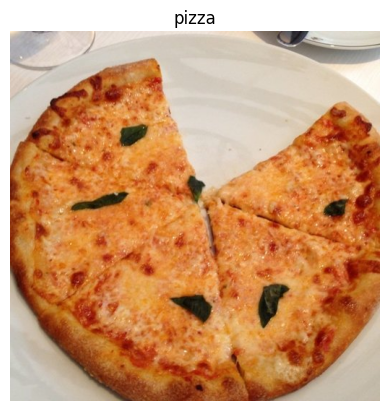

In [10]:
#view a random image from the training dataset
img = view_random_image(target_dir ='pizza_steak/train/',
                        target_class ='pizza')

In [11]:
# view the image shape
img.shape

(512, 512, 3)

In [12]:
#get all the pixel values between 0 and 1
img/225.

array([[[1.13333333, 1.06222222, 0.93333333],
        [1.13333333, 1.05333333, 0.92444444],
        [1.13333333, 1.04      , 0.91111111],
        ...,
        [0.97777778, 0.94222222, 0.88444444],
        [0.97777778, 0.94222222, 0.88444444],
        [0.98222222, 0.94666667, 0.88888889]],

       [[1.11555556, 1.02222222, 0.90222222],
        [1.10222222, 1.01777778, 0.88444444],
        [1.09777778, 1.00444444, 0.88444444],
        ...,
        [0.96888889, 0.93333333, 0.87555556],
        [0.96888889, 0.93333333, 0.87555556],
        [0.96444444, 0.92888889, 0.87111111]],

       [[1.07111111, 0.98222222, 0.87111111],
        [1.05777778, 0.98222222, 0.85777778],
        [1.06222222, 0.97333333, 0.86222222],
        ...,
        [0.96      , 0.92888889, 0.85777778],
        [0.96      , 0.92888889, 0.85777778],
        [0.95555556, 0.92444444, 0.85333333]],

       ...,

       [[0.89777778, 0.89777778, 0.86222222],
        [0.89777778, 0.89777778, 0.86222222],
        [0.89777778, 0

Building an end to end convolutional neural network(cnn)

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#set a random seed
tf.random.set_seed(42)

#preprocess data (get all of the pixel values between 0 and 1, also called scaling/normalisation)
train_datagen = ImageDataGenerator(rescale =1./255)
valid_datagen = ImageDataGenerator(rescale=1./255)
#setup path to our data directories

train_dir = '/content/pizza_steak/train'
test_dir = '/content/pizza_steak/test'

#impory data from directories and turn it into batches

train_data = train_datagen.flow_from_directory(directory=train_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode = 'binary',
                                               seed=42)

valid_data = valid_datagen.flow_from_directory(directory=test_dir,
                                               batch_size=32,
                                               target_size=(224,224),
                                               class_mode ='binary',
                                               seed=42)


#Build a CNN model (same as the tiny VGG on the CNN explainer website)
model_1 = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(filters=10,
                           kernel_size=3,
                           activation='relu',
                           input_shape=(224,224,3)),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.MaxPool2D(pool_size=2,
                              padding='valid'),
    tf.keras.layers.Conv2D(10,3, activation='relu'),
    tf.keras.layers.Conv2D(10,3, activation= 'relu'),
    tf.keras.layers.MaxPool2D(2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#compile the model

model_1.compile(loss= 'binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])
#fit the model

history_1 = model_1.fit(train_data,
                      epochs=5,
                      steps_per_epoch=len(train_data),
                      validation_data=valid_data,
                      validation_steps=len(valid_data))

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 18s 246ms/step - accuracy: 0.5331 - loss: 0.6962 - val_accuracy: 0.7700 - val_loss: 0.4660
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.8005 - loss: 0.4542 - val_accuracy: 0.8760 - val_loss: 0.3263
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step - accuracy: 0.8429 - loss: 0.3627 - val_accuracy: 0.8700 - val_loss: 0.3590
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.8408 - loss: 0.3814 - val_accuracy: 0.8860 - val_loss: 0.3172
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.8626 - loss: 0.3324 - val_accuracy: 0.8880 - val_loss: 0.2916


note if the above cell is taking longer than -10 second make sure you change the runtime

In [14]:
#get a model summary

model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 110, 110, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 108, 108, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 106, 106, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 53, 53, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28090)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        28,091 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,305 (364.48 KB)

 Trainable params: 31,101 (121.49 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,204 (242.99 KB)

In [15]:
#Using the same model as before
# set random seed

tf.random.set_seed(42)

#create a model to replicate the tensorflow playground
model_2 =tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(224,224,3)),
    tf.keras.layers.Dense(4, activation='relu'),
    tf.keras.layers.Dense(4, activation= 'relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

#compile the model
model_2.compile(loss='binary_crossentropy',
                optimizer=tf.keras.optimizers.Adam(),
                metrics=['accuracy'])

#Fit the model
history_2 = model_2.fit(train_data,
                        epochs=5,
                        steps_per_epoch=len(train_data),
                        validation_data= valid_data,
                        validation_steps = len(valid_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 150ms/step - accuracy: 0.4782 - loss: 1.1983 - val_accuracy: 0.5000 - val_loss: 0.6876
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step - accuracy: 0.5180 - loss: 0.6690 - val_accuracy: 0.7520 - val_loss: 0.5851
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 10s 105ms/step - accuracy: 0.7593 - loss: 0.5885 - val_accuracy: 0.7720 - val_loss: 0.5692
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.7435 - loss: 0.5807 - val_accuracy: 0.7260 - val_loss: 0.5840
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 108ms/step - accuracy: 0.7616 - loss: 0.5677 - val_accuracy: 0.7540 - val_loss: 0.5599


Binary Classification


['3663518.jpg']
image shape: (512, 512, 3)
['786995.jpg']
image shape: (384, 512, 3)


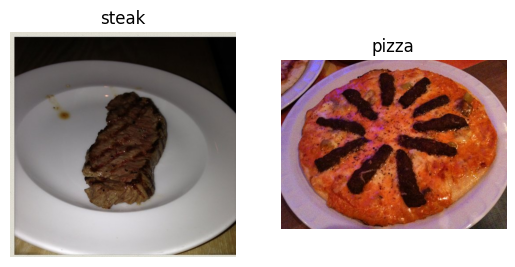

In [16]:
#Becoming one with the data
#visualize the data
plt.figure()
plt.subplot(1,2,1)
steak_img = view_random_image('pizza_steak/train/','steak')
plt.subplot(1,2,2)
pizza_img = view_random_image('pizza_steak/train/','pizza')


In [17]:
#Preprocess the data(prepare it for a model)
#Define directory dataset path
train_dir ='pizza_steak/train'
test_dir = 'pizza_staek/test'


A Batch is a small subset of data

In [18]:
!nvidia-smi

Wed Jan 28 20:48:39 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   54C    P0             29W /   70W |    1178MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [19]:
#create train and test data generator and rescale the data
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale=1/255.)
test_datagen = ImageDataGenerator(rescale=1/255.)

In [25]:
#load in our image data from directories and turn them into batches
train_data= train_datagen.flow_from_directory(directory=train_dir,
                                        target_size=(224,224),
                                         class_mode='binary',
                                         batch_size=32)

# Correct the typo in test_dir before using it
test_dir = 'pizza_steak/test'

test_data =test_datagen.flow_from_directory(test_dir,
                                       target_size=(224,224),
                                       class_mode='binary',
                                       batch_size=32)

Found 1500 images belonging to 2 classes.
Found 500 images belonging to 2 classes.


In [26]:
#Get a sample of a train data bacth
images, labels = next(train_data)
len(images), len(labels)

(32, 32)

In [27]:
#get the fisrt two images
images[:2], images[0].shape

(array([[[[0.30588236, 0.17254902, 0.227451  ],
          [0.34901962, 0.21960786, 0.25490198],
          [0.4039216 , 0.2784314 , 0.2901961 ],
          ...,
          [0.16470589, 0.02745098, 0.1137255 ],
          [0.16862746, 0.01960784, 0.11764707],
          [0.15686275, 0.00784314, 0.10588236]],
 
         [[0.28235295, 0.14901961, 0.20392159],
          [0.34117648, 0.21176472, 0.24705884],
          [0.42352945, 0.29803923, 0.30980393],
          ...,
          [0.17254902, 0.02352941, 0.1137255 ],
          [0.1764706 , 0.02745098, 0.11764707],
          [0.16078432, 0.01176471, 0.10980393]],
 
         [[0.26666668, 0.13333334, 0.19607845],
          [0.32941177, 0.20000002, 0.23529413],
          [0.42352945, 0.29803923, 0.31764707],
          ...,
          [0.19215688, 0.04313726, 0.13333334],
          [0.1764706 , 0.02745098, 0.11764707],
          [0.16862746, 0.03137255, 0.1254902 ]],
 
         ...,
 
         [[0.62352943, 0.5803922 , 0.5647059 ],
          [0.60392

In [28]:
#view the fisrt batch of labels
labels

array([1., 0., 0., 0., 1., 0., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0.,
       0., 1., 1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0.],
      dtype=float32)

In [29]:
#Create the cnn model(start with the baseline)
#Make the creating of our model a litle easier
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPool2D, Activation
from tensorflow.keras import Sequential

#Create the model
model_4 = Sequential([
    Conv2D(filters=10,#filter is the sliding window going across an input higher more ocmplex model
          kernel_size=3,# the size of the sliding window going across an input
          strides=1,# the size of the step the sliding window takes acros an input
          padding='same',# is same output shape is same as input sahpe but if valid output value get compressed
          activation='relu',
          input_shape=(224,224,3)),
    Conv2D(10,3, activation='relu'),
    Conv2D(10,3, activation='relu'),
    Flatten(),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [30]:
#Compile and fittingg the baseline model
model_4.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

#get the summary
model_4.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 224, 224, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 222, 222, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 220, 220, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 484000)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │       484,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 486,101 (1.85 MB)

 Trainable params: 486,101 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
#Fit the model
#Checks the lenght of training and test data generators
len(train_data), len(test_data)

(47, 16)

In [32]:
history_4=model_4.fit(train_data,
                    epochs=5,
                    steps_per_epoch=len(train_data),
                    validation_data= test_data,
                    validation_steps=len(test_data))

Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


47/47 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - accuracy: 0.4914 - loss: 0.9025 - val_accuracy: 0.6880 - val_loss: 0.5940
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 119ms/step - accuracy: 0.7294 - loss: 0.5309 - val_accuracy: 0.8400 - val_loss: 0.4143
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8375 - loss: 0.3656 - val_accuracy: 0.8360 - val_loss: 0.3953
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 137ms/step - accuracy: 0.9449 - loss: 0.1754 - val_accuracy: 0.8180 - val_loss: 0.4201
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 9s 109ms/step - accuracy: 0.9841 - loss: 0.0699 - val_accuracy: 0.8080 - val_loss: 0.4781


In [33]:
model_1.evaluate(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - accuracy: 0.8828 - loss: 0.3074


[0.2915595769882202, 0.8880000114440918]

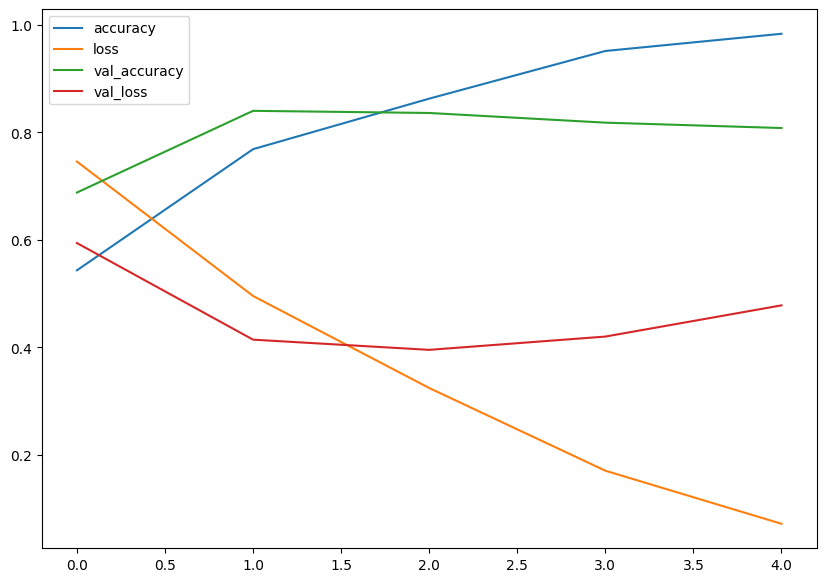

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

pd.DataFrame(history_4.history).plot(figsize=(10, 7))
plt.show()

In [35]:
#plot the validation and training curves seperately
def plot_loss_curves(history):

  loss = history.history['loss']
  val_loss = history.history['val_loss']

  accuracy = history.history['accuracy']
  val_accuracy = history.history['val_accuracy']

  epochs = range(len(history.history['loss']))

  #plot loss
  plt.plot(epochs, loss ,label= 'training_loss')
  plt.plot(epochs, val_loss,label= 'val_loss')
  plt.title('Loss')
  plt.xlabel('Epochs')
  plt.legend()


  #plot accuracy
  plt.figure()
  plt.plot(epochs, accuracy, label='training_accuracy')
  plt.plot(epochs, val_accuracy, label='val_accuracy')
  plt.title('Accuracy')
  plt.xlabel('Epochs')
  plt.legend()
  plt.show()

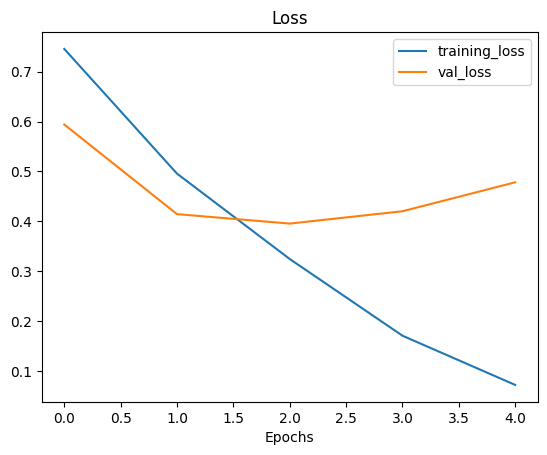

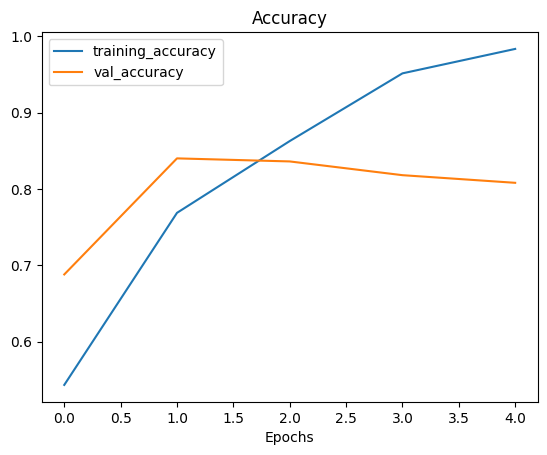

In [36]:
#check out the loss and accuracy of model
plot_loss_curves(history_4)

In [37]:
#Reducing overfitting with maxpool
#0. create a baseline
#1. Beat the baseline by overfitting a larger model
#2. Reduce the overfiting

#ways to induce overfitting :
# increase the number of conv layer
#increase the number of conv filter
# Add another dense layer to the output of our flattened layer
#Reduce to overfitting

#Add data augmentation
#Add regularization layers(such as maxpool)
#Add more data


In [40]:
#create a model
model_5=Sequential([
    Conv2D(10,3, activation='relu', input_shape=(224, 224,3)),
    MaxPool2D(pool_size=2),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Conv2D(10,3,activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1,activation='sigmoid')
])

In [45]:
#Compile the model
model_5.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

#Fit the model
history_5=model_5.fit(train_data,
            epochs=5,
            steps_per_epoch =len(train_data),
            validation_data=test_data,
            validation_steps=len(valid_data),
            )

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 182ms/step - accuracy: 0.8365 - loss: 0.3850 - val_accuracy: 0.8620 - val_loss: 0.3196
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 116ms/step - accuracy: 0.8785 - loss: 0.3188 - val_accuracy: 0.8860 - val_loss: 0.2849
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.8852 - loss: 0.3080 - val_accuracy: 0.8920 - val_loss: 0.2862
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.8918 - loss: 0.2836 - val_accuracy: 0.8720 - val_loss: 0.3154
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 11s 127ms/step - accuracy: 0.8986 - loss: 0.2793 - val_accuracy: 0.8820 - val_loss: 0.3008


In [46]:

#get the summary
model_5.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 222, 222, 10)   │           280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 111, 111, 10)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 109, 109, 10)   │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 54, 54, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 52, 52, 10)     │           910 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 26, 26, 10)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 6760)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         6,761 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,585 (103.85 KB)

 Trainable params: 8,861 (34.61 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,724 (69.24 KB)

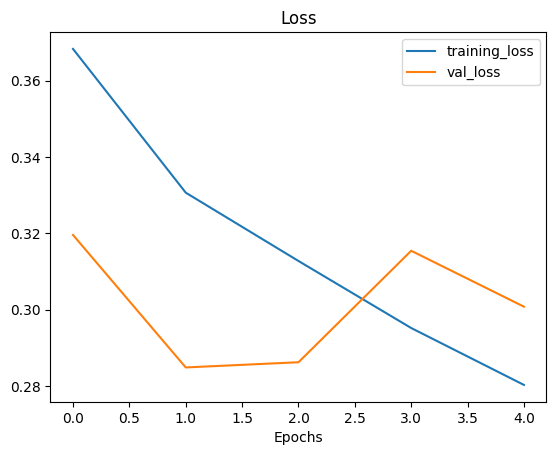

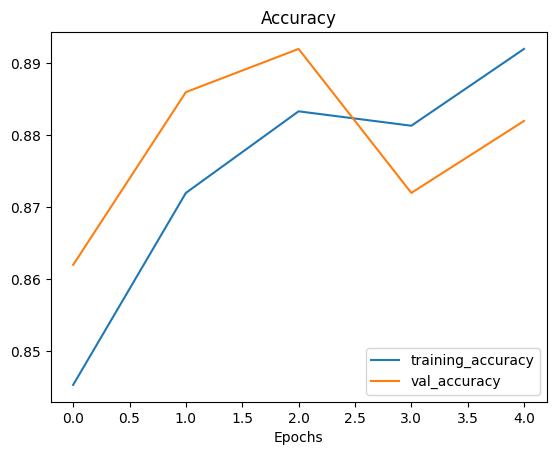

In [47]:
#plot loss curves
plot_loss_curves(history_5)

In [49]:
#Create ImageDataGenerator training instance with data augmentation
train_datagen_augmented = ImageDataGenerator(rescale=1/255.,
                                             rotation_range=0.2,
                                             shear_range=0.2,
                                             zoom_range=0.2,
                                             width_shift_range=0.2,
                                             height_shift_range=0.3,
                                             horizontal_flip=True)

#Create ImageDataGenerator without data augmentation
train_datagen = ImageDataGenerator(rescale=1/255.)

test_datagen = ImageDataGenerator(rescale=1/255.)

In [53]:
#import data and augment it from training directory
print('Augmented Training data')
train_datagen_augmented.flow_from_directory(train_dir,
                                            target_size=(224, 224),
                                            batch_size=32,
                                            class_mode='binary',
                                            shuffle=False)#for demonstration purpose only

#Create nonaugmented train data batch
print('Non-Augmented Training data')
train_data = train_datagen.flow_from_directory(train_dir,
                                               target_size=(224 ,224),
                                               batch_size=32,
                                               class_mode ='binary',
                                               shuffle=False)
IMG_SIZE = (224,224)

#Create non-augmented test data batches
print('Non-Augmented Test data')
test_data = test_datagen.flow_from_directory(test_dir,
                                             target_size=IMG_SIZE,
                                             batch_size=32,
                                             class_mode='binary')


Augmented Training data
Found 1500 images belonging to 2 classes.
Non-Augmented Training data
Found 1500 images belonging to 2 classes.
Non-Augmented Test data
Found 500 images belonging to 2 classes.


In [54]:
#lets visulaize some data batch
images, labels = next(train_data)
augmented_images, augmented_labels = next(train_datagen_augmented)

showing image number: 29


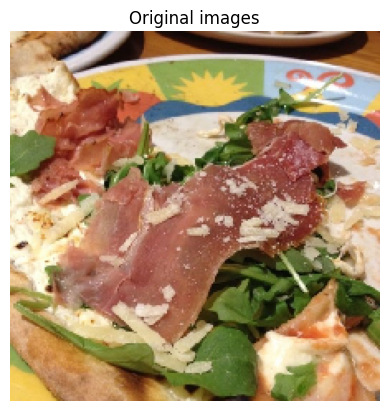

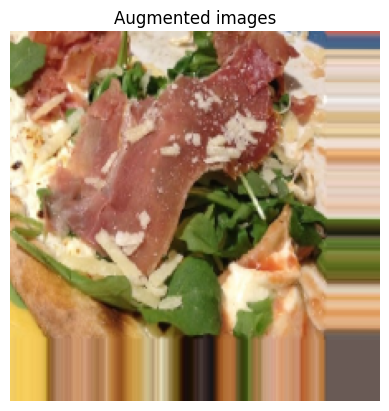

In [59]:
#show the original image
import random
random_number = random.randint(0,32)

print(f'showing image number: {random_number}')
plt.imshow(images[random_number])
plt.title(f'Original images')
plt.axis(False)
plt.figure()
plt.imshow(augmented_images[random_number])
plt.title(f'Augmented images')
plt.axis(False);


In [64]:
#create a model on augmented data
model_6 = Sequential([
    Conv2D(10,3, activation='relu'),
    MaxPool2D(pool_size=2),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1, activation= 'sigmoid')
])

#compile the model
model_6.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

history_6 = model_6.fit(train_data_augmented,
            epochs=5,
            steps_per_epoch=len(train_data_augmented),
            validation_data=test_data,
            validation_steps=len(test_data))

Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 28s 524ms/step - accuracy: 0.4887 - loss: 0.7433 - val_accuracy: 0.7020 - val_loss: 0.6795
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 477ms/step - accuracy: 0.4979 - loss: 0.6955 - val_accuracy: 0.7280 - val_loss: 0.6807
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 22s 471ms/step - accuracy: 0.5341 - loss: 0.6976 - val_accuracy: 0.5420 - val_loss: 0.6848
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 485ms/step - accuracy: 0.4751 - loss: 0.6909 - val_accuracy: 0.5140 - val_loss: 0.6667
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 23s 490ms/step - accuracy: 0.6202 - loss: 0.6453 - val_accuracy: 0.7860 - val_loss: 0.6330


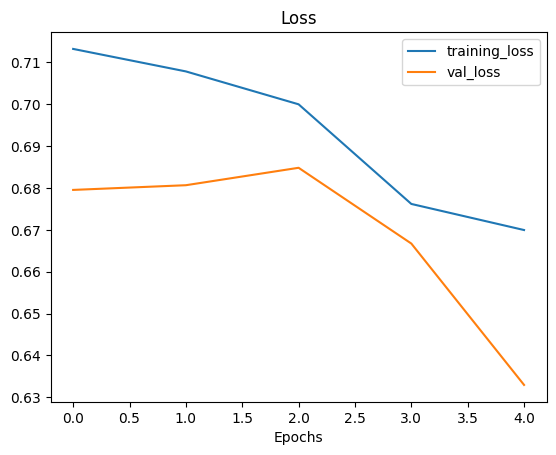

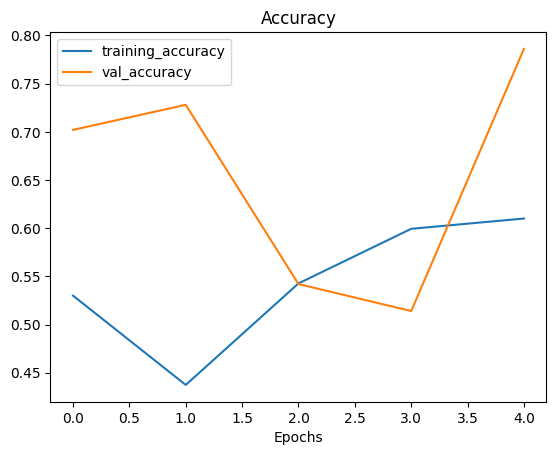

In [65]:
#Check our model
plot_loss_curves(history_6)

In [66]:
#import data and augment it and shuffle from training directory
train_data_augmented_shuffled = train_datagen_augmented.flow_from_directory(train_dir,
                                                                            target_size=(224,224),
                                                                            class_mode='binary',
                                                                            batch_size=32,
                                                                            shuffle=True,
                                                                            )

Found 1500 images belonging to 2 classes.


In [67]:
#create the model
model_7 =Sequential([
    Conv2D(10,3, activation='relu',input_shape=(224,224,3)),
    MaxPool2D(pool_size=2),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Conv2D(10,3, activation='relu'),
    MaxPool2D(),
    Flatten(),
    Dense(1,activation='sigmoid')
])

#Compile the model
model_7.compile(loss='binary_crossentropy',
                optimizer=Adam(),
                metrics=['accuracy'])

history_7 = model_7.fit(train_data_augmented_shuffled,
                        epochs=5,
                        steps_per_epoch=len(train_data_augmented_shuffled),
                        validation_data=test_data,
                        validation_steps=len(test_data))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 29s 552ms/step - accuracy: 0.5397 - loss: 0.6964 - val_accuracy: 0.7040 - val_loss: 0.5982
Epoch 2/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 506ms/step - accuracy: 0.6636 - loss: 0.6173 - val_accuracy: 0.8040 - val_loss: 0.4294
Epoch 3/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 503ms/step - accuracy: 0.7002 - loss: 0.5584 - val_accuracy: 0.8380 - val_loss: 0.3810
Epoch 4/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 44s 557ms/step - accuracy: 0.7623 - loss: 0.4902 - val_accuracy: 0.8400 - val_loss: 0.3800
Epoch 5/5
47/47 ━━━━━━━━━━━━━━━━━━━━ 24s 505ms/step - accuracy: 0.7760 - loss: 0.4838 - val_accuracy: 0.8480 - val_loss: 0.3506


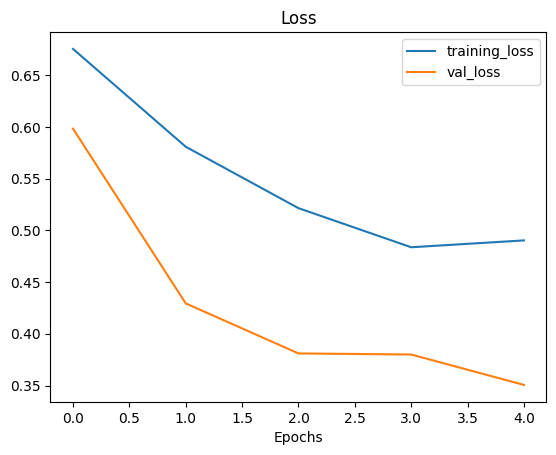

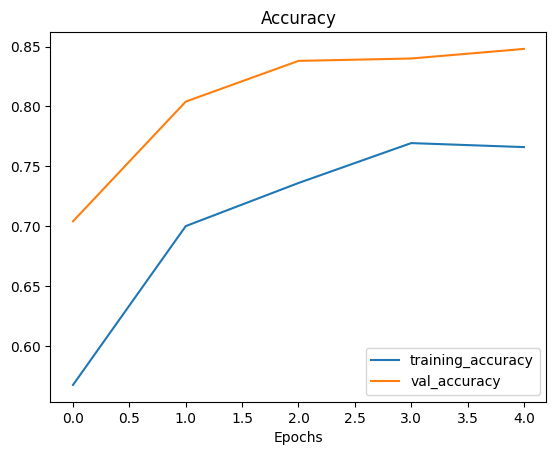

In [68]:
plot_loss_curves(history_7)